## EDA - Olist (cleaned)

This notebook is **EDA only**.

**Input expected:** cleaned outputs exported from `notebooks/01_data_understanding_cleaning.ipynb` into `../data/processed/`.

**Goal:** extract the strongest, most defensible insights around late delivery risk and highlight data quality or leakage risks that matter for modeling and business decisions.


In [1]:
from __future__ import annotations

import math
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams["figure.figsize"] = (12, 6)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


### Step 1 - Load cleaned data and wire EDA inputs

This cell prefers the cleaned Olist outputs from `../data/processed/` generated by `01_data_understanding_cleaning.ipynb`.

- If the cleaned per-table files are present, we merge them into one EDA-ready DataFrame.
- If a single pre-merged cleaned file is present, we load it directly.
- As a fallback, we can still load a legacy single-file cleaned dataset.

We then preview shape and first rows to confirm everything is connected.

In [2]:
# ---- Data loading: prefer cleaned Olist outputs ----

PROCESSED_DIR = Path("..").joinpath("data", "processed")

# Optional one-file merged cleaned dataset path candidates.
MERGED_CANDIDATE_PATHS = [
    PROCESSED_DIR.joinpath("olist_eda_ready.csv"),
    PROCESSED_DIR.joinpath("olist_merged_clean.csv"),
    PROCESSED_DIR.joinpath("merged_clean.csv"),
]

# Legacy fallback (kept so this notebook remains backward-compatible).
LEGACY_SINGLE_FILE_PATHS = [
    Path("..").joinpath("data", "dataco_cleaned.csv"),
    Path("dataco_cleaned.csv"),
    Path("..").joinpath("notebooks", "dataco_cleaned.csv"),
]

# Per-table cleaned outputs from 01_data_understanding_cleaning.ipynb
REQUIRED_OLIST_TABLES = {
    "orders": "orders_clean.csv",
    "items": "items_clean.csv",
    "payments": "payments_clean.csv",
    "reviews": "reviews_clean.csv",
    "customers": "customers_clean.csv",
    "sellers": "sellers_clean.csv",
    "products": "products_clean.csv",
    "translation": "translation_clean.csv",
}


def _load_olist_from_processed(processed_dir: Path) -> pd.DataFrame:
    paths = {name: processed_dir.joinpath(filename) for name, filename in REQUIRED_OLIST_TABLES.items()}
    missing = [str(p) for p in paths.values() if not p.exists()]
    if missing:
        joined = "\n".join(f"- {m}" for m in missing)
        raise FileNotFoundError(
            "Missing cleaned Olist table exports in ../data/processed/.\n"
            "Please run notebooks/01_data_understanding_cleaning.ipynb first.\n\n"
            f"Missing files:\n{joined}"
        )

    tables = {name: pd.read_csv(path) for name, path in paths.items()}

    orders = tables["orders"].copy()
    items = tables["items"].copy()
    payments = tables["payments"].copy()
    reviews = tables["reviews"].copy()
    customers = tables["customers"].copy()
    sellers = tables["sellers"].copy()
    products = tables["products"].copy()
    translation = tables["translation"].copy()

    # Normalize datetime columns used by EDA.
    for col in [
        "order_purchase_timestamp",
        "order_estimated_delivery_date",
        "order_delivered_customer_date",
        "order_approved_at",
        "order_delivered_carrier_date",
    ]:
        if col in orders.columns:
            orders[col] = pd.to_datetime(orders[col], errors="coerce")

    if "review_creation_date" in reviews.columns:
        reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")

    # Category translation (Portuguese -> English when available).
    products = products.merge(
        translation,
        on="product_category_name",
        how="left",
        validate="m:1",
    )
    products["category_name"] = products["product_category_name_english"].fillna(products["product_category_name"])

    # Aggregate multi-row payments to order level.
    payments_agg = (
        payments.groupby("order_id", as_index=False)
        .agg(
            payment_value=("payment_value", "sum"),
            payment_installments=("payment_installments", "max"),
            payment_type_nunique=("payment_type", "nunique"),
        )
    )

    # Collapse reviews to one row per order.
    if "review_creation_date" in reviews.columns:
        reviews = reviews.sort_values("review_creation_date")
    reviews_agg = (
        reviews.groupby("order_id", as_index=False)
        .agg(
            review_score=("review_score", "mean"),
            review_polarity=("review_polarity", "first"),
        )
    )

    # Build item-level modeling frame.
    df = (
        items
        .merge(orders, on="order_id", how="inner", validate="m:1")
        .merge(customers, on="customer_id", how="left", validate="m:1")
        .merge(sellers, on="seller_id", how="left", validate="m:1")
        .merge(products, on="product_id", how="left", validate="m:1")
        .merge(payments_agg, on="order_id", how="left", validate="m:1")
        .merge(reviews_agg, on="order_id", how="left", validate="m:1")
    )

    # Add EDA-standardized columns used across this notebook.
    if "is_late" in df.columns:
        df["late_delivery_risk"] = df["is_late"].astype("int64")

    if "delivery_days" in df.columns:
        df["shipping_days_actual"] = df["delivery_days"]

    if {"order_estimated_delivery_date", "order_purchase_timestamp"}.issubset(df.columns):
        scheduled_days = (df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]).dt.days
        df["shipping_days_scheduled"] = scheduled_days

    if "order_purchase_timestamp" in df.columns:
        df["order_date"] = df["order_purchase_timestamp"]

    if "order_delivered_customer_date" in df.columns:
        df["shipping_date"] = df["order_delivered_customer_date"]

    if "price" in df.columns:
        df["product_price"] = df["price"]
        df["item_sales"] = df["price"]

    if "freight_value" in df.columns and "price" in df.columns:
        df["item_total"] = df["price"] + df["freight_value"]

    if "customer_id" in df.columns and "item_total" in df.columns:
        df["customer_total_sales"] = df.groupby("customer_id")["item_total"].transform("sum")

    # Compatibility placeholders for charts expecting these fields.
    if "item_quantity" not in df.columns:
        df["item_quantity"] = 1
    if "item_discount_amount" not in df.columns:
        df["item_discount_amount"] = 0.0
    if "item_discount_rate" not in df.columns:
        df["item_discount_rate"] = 0.0

    # Optional geo aliases; plot will skip if these are absent.
    if "geolocation_lat" in df.columns:
        df["store_latitude"] = df["geolocation_lat"]
    if "geolocation_lng" in df.columns:
        df["store_longitude"] = df["geolocation_lng"]

    # Add stable context fields used by categorical slices.
    df["order_country"] = "Brazil"

    return df


def load_cleaned_df(path: str | Path | None = None) -> pd.DataFrame:
    if path is not None:
        p = Path(path)
        if not p.exists():
            raise FileNotFoundError(f"File not found: {p.resolve()}")
        print(f"Loading explicit path: {p}")
        return pd.read_csv(p)

    # 1) Preferred: single merged cleaned file, if already prepared.
    for p in MERGED_CANDIDATE_PATHS:
        if p.exists():
            print(f"Loading merged cleaned file: {p}")
            return pd.read_csv(p)

    # 2) Preferred in this project: build EDA frame from cleaned per-table outputs.
    if PROCESSED_DIR.exists():
        print(f"Building EDA dataframe from cleaned tables in: {PROCESSED_DIR}")
        return _load_olist_from_processed(PROCESSED_DIR)

    # 3) Legacy fallback.
    for p in LEGACY_SINGLE_FILE_PATHS:
        if p.exists():
            print(f"Loading legacy single-file cleaned dataset: {p}")
            return pd.read_csv(p)

    searched = (
        [str(p.resolve()) for p in MERGED_CANDIDATE_PATHS]
        + [str(PROCESSED_DIR.resolve())]
        + [str(p.resolve()) for p in LEGACY_SINGLE_FILE_PATHS]
    )
    searched_text = "\n".join(f"- {s}" for s in searched)
    raise FileNotFoundError(
        "No compatible cleaned dataset was found.\n\n"
        "Expected one of the following:\n"
        "1) cleaned per-table exports in ../data/processed/ from 01_data_understanding_cleaning.ipynb\n"
        "2) a merged cleaned CSV in ../data/processed/\n"
        "3) legacy dataco_cleaned.csv fallback\n\n"
        f"Searched paths:\n{searched_text}"
    )


df = load_cleaned_df()
print(df.shape)
df.head(3)


Loading merged cleaned file: ..\data\processed\olist_eda_ready.csv
(110180, 56)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,is_high_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_late,is_delivered,delivery_status,delivery_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_valid_city_x,seller_zip_code_prefix,seller_city,seller_state,is_valid_city_y,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,category_name,payment_value,payment_installments,payment_type_nunique,review_score,review_polarity,late_delivery_risk,shipping_days_actual,shipping_days_scheduled,order_date,shipping_date,product_price,item_sales,item_total,customer_total_sales,item_quantity,item_discount_amount,item_discount_rate,order_country
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,0,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,0,1,early,7,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,1,27277,volta redonda,SP,1,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,cool_stuff,72.19,2.0,1.0,5.0,positive,0,7,15,2017-09-13 08:59:02,2017-09-20 23:43:48,58.9,58.9,72.19,72.19,1,0.0,0.0,Brazil
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,0,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,0,1,early,16,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,1,3471,sao paulo,SP,1,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,pet_shop,259.83,3.0,1.0,4.0,positive,0,16,18,2017-04-26 10:53:06,2017-05-12 16:04:24,239.9,239.9,259.83,259.83,1,0.0,0.0,Brazil
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,0,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,0,1,early,7,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,1,37564,borda da mata,MG,1,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,furniture_decor,216.87,5.0,1.0,5.0,positive,0,7,21,2018-01-14 14:33:31,2018-01-22 13:19:16,199.0,199.0,216.87,216.87,1,0.0,0.0,Brazil


### Step 2 – Check structure, duplicates, and missing values

In this step we answer:
- *What columns and dtypes do we have?* → `df.info()`
- *Are there duplicated rows?* → `df.duplicated()`
- *Do we still have any missing values? In which columns and how much?* → we compute a small **missingness table** and (if needed) plot a bar chart of missing % per column.

This gives a **quick health check** that the cleaned dataset is consistent and complete.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110180 entries, 0 to 110179
Data columns (total 56 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       110180 non-null  object 
 1   order_item_id                  110180 non-null  int64  
 2   product_id                     110180 non-null  object 
 3   seller_id                      110180 non-null  object 
 4   shipping_limit_date            110180 non-null  object 
 5   price                          110180 non-null  float64
 6   freight_value                  110180 non-null  float64
 7   is_high_value                  110180 non-null  int64  
 8   customer_id                    110180 non-null  object 
 9   order_status                   110180 non-null  object 
 10  order_purchase_timestamp       110180 non-null  object 
 11  order_approved_at              110180 non-null  object 
 12  order_delivered_carrier_date  

None

Rows: 110,180 | Columns: 56
Exact duplicate rows: 0 (0.00%)


,missing,missing_%
product_category_name_english,1559,1.41
review_score,827,0.75
review_polarity,827,0.75
product_description_lenght,18,0.02
product_photos_qty,18,0.02
product_name_lenght,18,0.02
product_height_cm,18,0.02
product_length_cm,18,0.02
product_category_name,18,0.02
product_weight_g,18,0.02


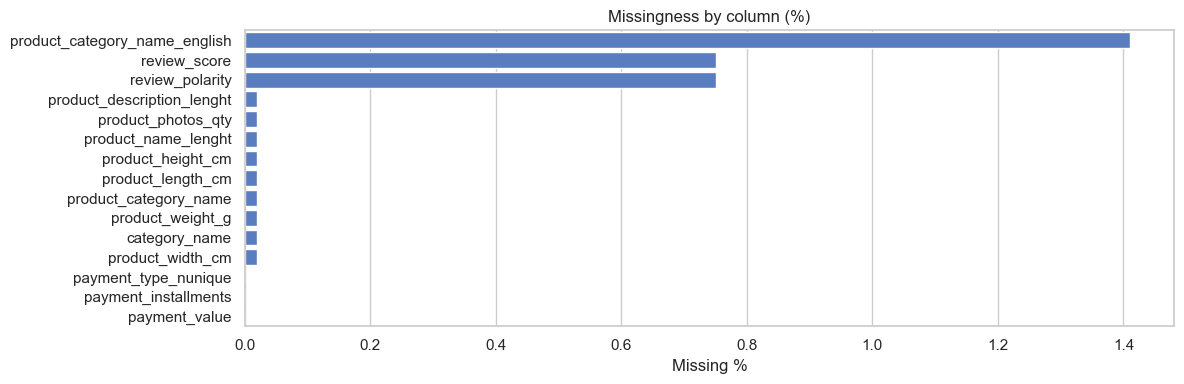

In [3]:
# ---- Quick structural audit ----

display(df.info())

n_rows, n_cols = df.shape
print(f"Rows: {n_rows:,} | Columns: {n_cols:,}")

# Duplicate rows (exact)
dup_n = int(df.duplicated().sum())
print(f"Exact duplicate rows: {dup_n:,} ({dup_n / max(n_rows, 1) * 100:.2f}%)")

# Missingness table
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_tbl = pd.DataFrame({"missing": missing, "missing_%": missing_pct})
missing_tbl = missing_tbl[missing_tbl["missing"] > 0]

if len(missing_tbl) == 0:
    print("No missing values.")
else:
    display(missing_tbl)
    plt.figure(figsize=(12, max(4, 0.25 * len(missing_tbl))))
    sns.barplot(
        data=missing_tbl.reset_index().rename(columns={"index": "column"}),
        y="column",
        x="missing_%",
        color=sns.color_palette()[0],
    )
    plt.title("Missingness by column (%)")
    plt.xlabel("Missing %")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


### Step 3 – Understand the target: `late_delivery_risk`

Goal: understand how imbalanced the **classification label** is.

- We check that the `late_delivery_risk` column exists.
- We count how many orders are **on time (0)** vs **late (1)**.
- We compute the **overall late rate** (percentage of orders that are late).
- We plot a simple **bar chart** to visualize class balance.
- We also compute a **majority-class baseline accuracy** (how good you’d be if you always predicted the most common class).

This tells us how hard the classification problem is and what baseline any model must beat.

late_delivery_risk
0    101466
1      8714
Name: count, dtype: int64
Late rate: 0.079 (7.9%)


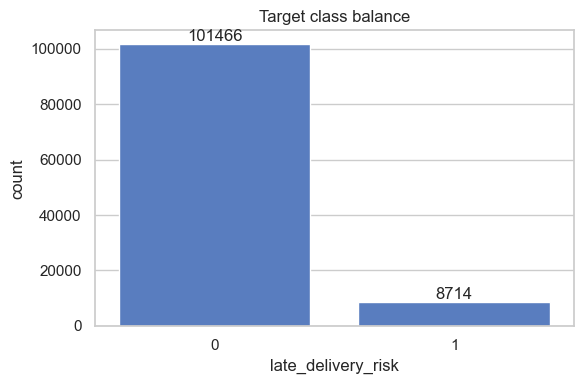

Majority-class baseline accuracy: 0.921 (predict 0 always)


In [4]:
# ---- Target overview (Late_delivery_risk) ----

TARGET = "late_delivery_risk"
if TARGET not in df.columns:
    raise KeyError(f"Expected target column not found: {TARGET}")

# Validate target values
vc = df[TARGET].value_counts(dropna=False).sort_index()
print(vc)

late_rate = df[TARGET].mean()
print(f"Late rate: {late_rate:.3f} ({late_rate*100:.1f}%)")

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=TARGET, data=df)
ax.bar_label(ax.containers[0])
plt.title("Target class balance")
plt.tight_layout()
plt.show()

# Helpful baseline for any classifier
majority = int(vc.idxmax()) if len(vc) else None
baseline_acc = float(vc.max() / len(df)) if len(df) else math.nan
print(f"Majority-class baseline accuracy: {baseline_acc:.3f} (predict {majority} always)")


### Step 4 – Check for potential leakage columns

Some columns describe **outcomes that happen after the prediction point**, not inputs we would know in advance (for example, actual shipping time or final delivery status).

- We highlight columns such as `shipping_days_actual`, `delivery_status`, and `shipping_date`.
- We print which of these are present in the cleaned data.
- For the numeric ones, we show how strongly they separate late vs non-late shipments.

These are **red-flag features** that must **not** be used as predictors in a real model, but it’s useful to see how powerful they are to understand the mechanics of the process.

Potential leakage columns present:
- shipping_days_actual
- delivery_status
- shipping_date
- order_delivered_customer_date


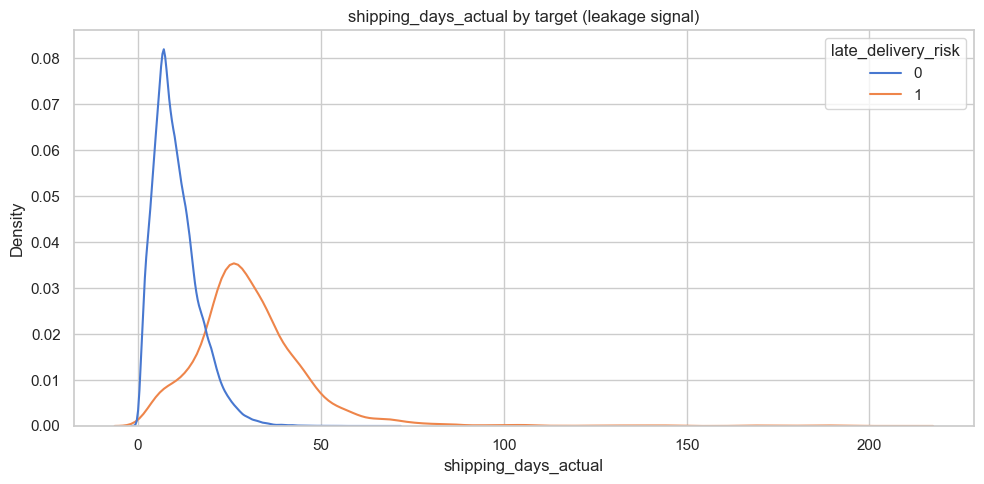

,mean,size
delivery_status,,
late,1.0,8714
early,0.0,101466


In [5]:
# ---- Leakage / post-event signals (must be excluded from model features) ----
# These columns encode outcomes that happen at/after delivery and can leak target info.

leakage_candidates = [
    "shipping_days_actual",
    "delivery_status",
    "shipping_date",
    "order_delivered_customer_date",
]

present = [c for c in leakage_candidates if c in df.columns]
print("Potential leakage columns present:")
for c in present:
    print("-", c)

# Show how strongly leakage-like fields separate target classes (EDA only).
if "shipping_days_actual" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df, x="shipping_days_actual", hue=TARGET, common_norm=False)
    plt.title("shipping_days_actual by target (leakage signal)")
    plt.tight_layout()
    plt.show()

if "delivery_status" in df.columns:
    tmp = (
        df.groupby("delivery_status")[TARGET]
        .agg(["mean", "size"])
        .sort_values(["mean", "size"], ascending=[False, False])
    )
    display(tmp)


### Step 5 – Numeric features: distributions and relationship with the target

Here we focus on **important numeric business variables** (quantities, prices, discounts, profits, etc.).

For each selected column we:
- Plot its **overall distribution** (histogram + KDE) to see shape, skewness, and outliers.
- Plot a **boxplot by `late_delivery_risk`** to check if late vs on-time orders have different distributions.

This helps answer questions like:
- *Are very high discounts associated with more late orders?*
- *Do very profitable / unprofitable orders behave differently in terms of delay?*

Numeric columns (excluding id-like + target): 30


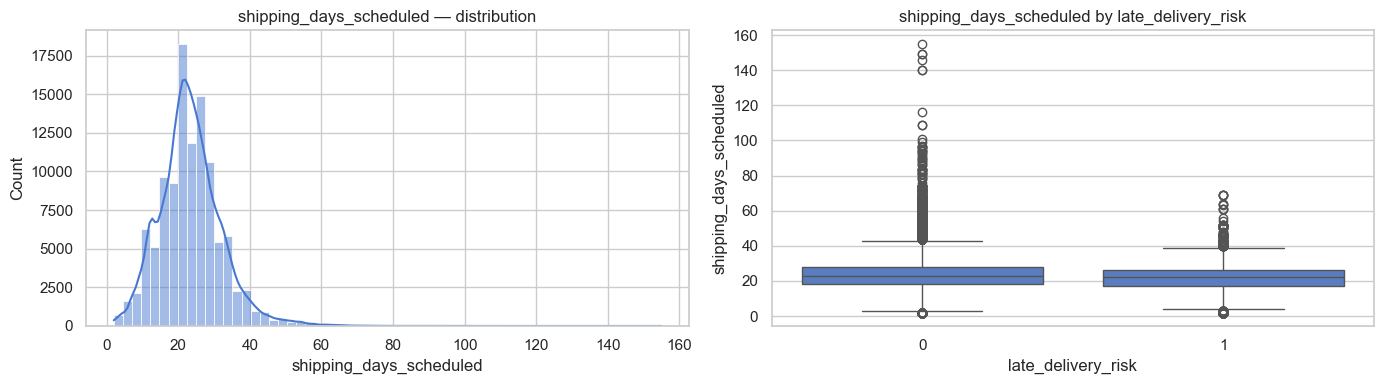

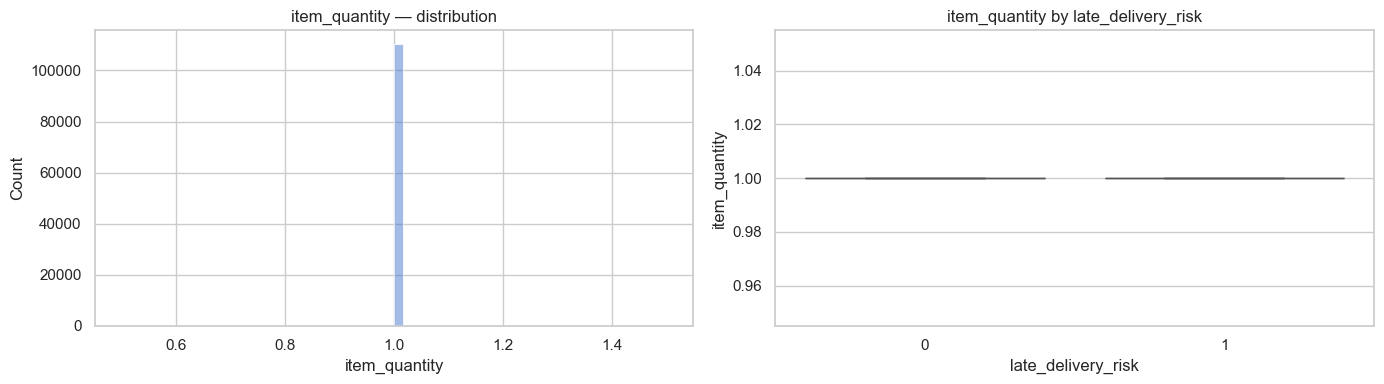

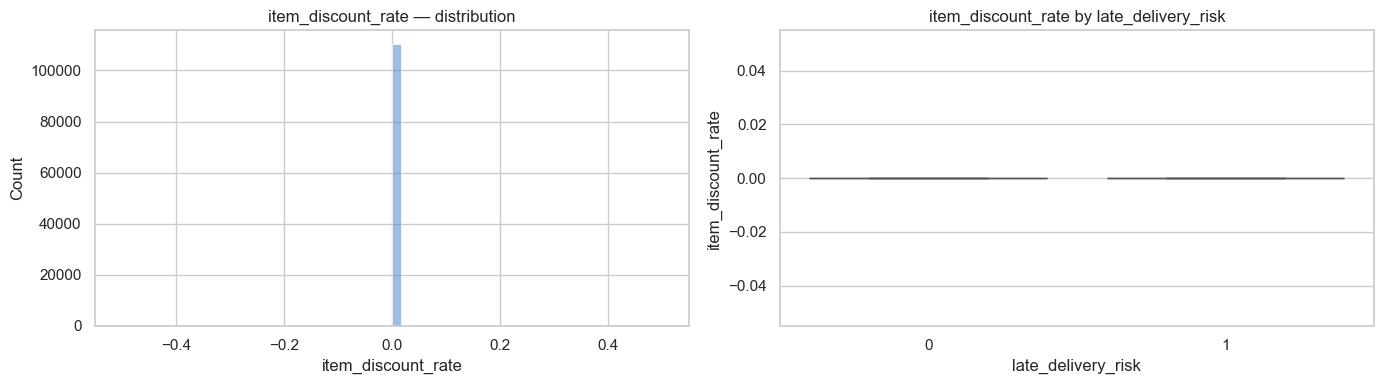

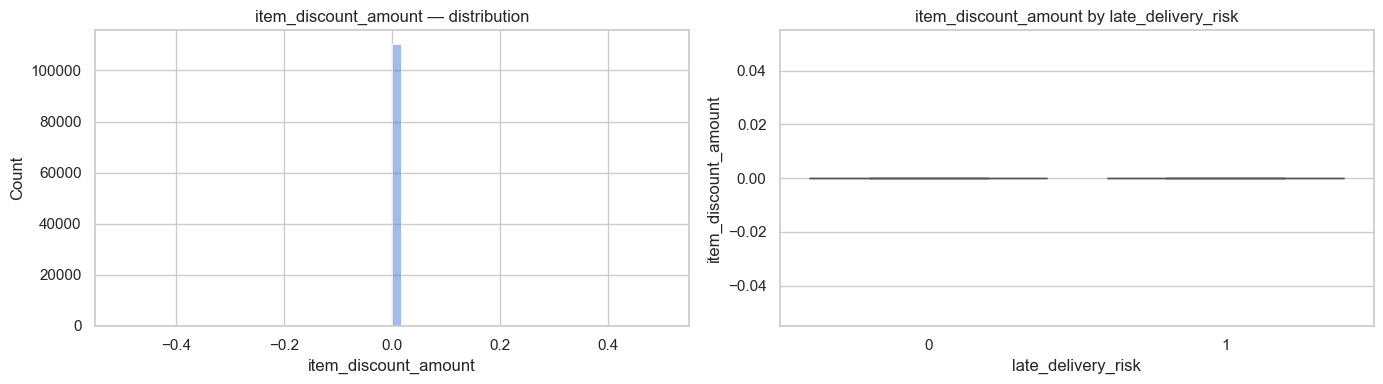

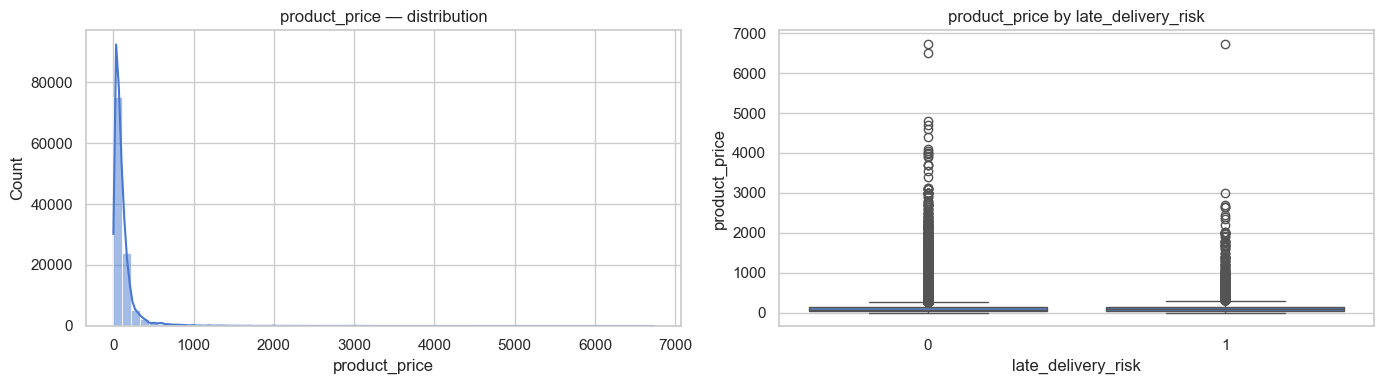

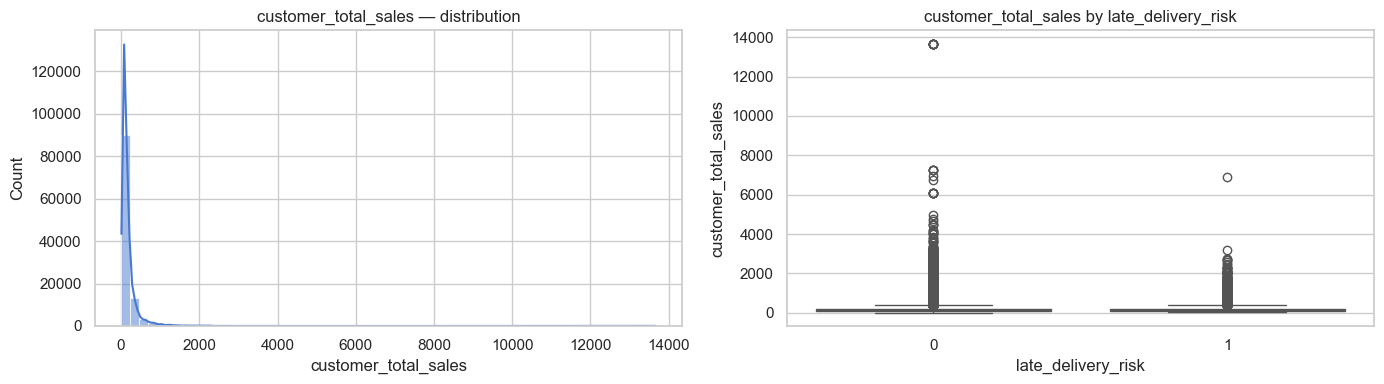

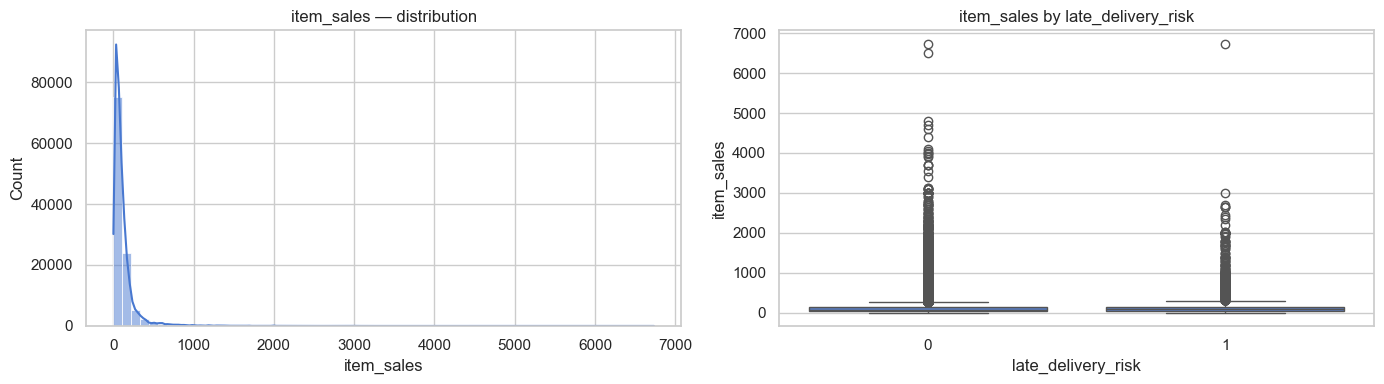

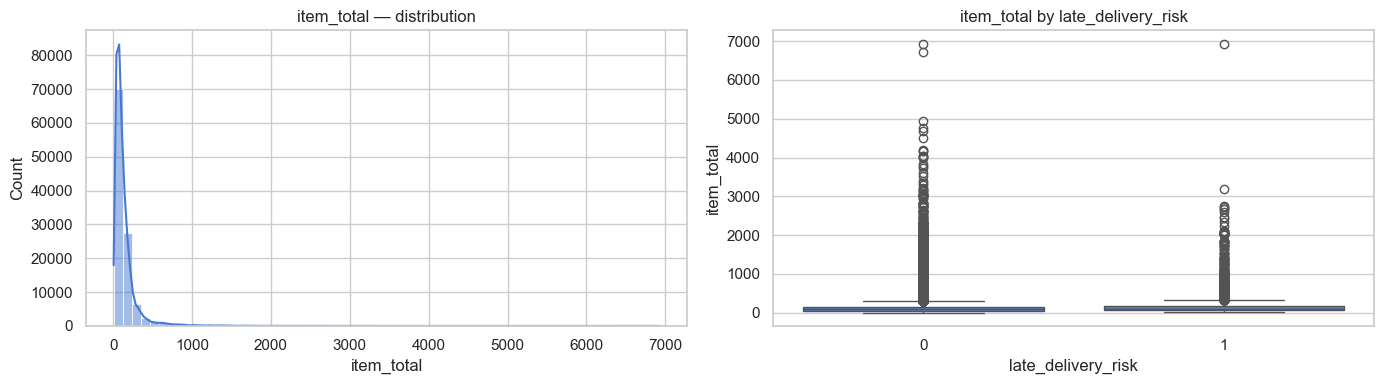

In [6]:
# ---- Numeric feature scan (univariate + by target) ----

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
# Exclude identifiers if present
id_like = [c for c in num_cols if c.lower().endswith(" id") or c.lower().endswith("id")]
num_cols = [c for c in num_cols if c not in id_like]

# Keep target out of feature scan
num_cols = [c for c in num_cols if c != TARGET]

print(f"Numeric columns (excluding id-like + target): {len(num_cols)}")

# Choose a high-signal subset for deep dives (finance + shipping schedule)
preferred = [
    "shipping_days_scheduled",
    "item_quantity",
    "item_discount_rate",
    "item_discount_amount",
    "product_price",
    "Order Item Product Price",
    "customer_total_sales",
    "item_sales",
    "item_total",
    "profit_per_order",
    "item_profit_ratio",
    "profit_ratio_extreme_loss",
]

focus_num = [c for c in preferred if c in df.columns]
if len(focus_num) == 0:
    focus_num = num_cols[:12]

for c in focus_num:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(df[c], bins=60, ax=axes[0], kde=True)
    axes[0].set_title(f"{c} — distribution")

    # robust visualization for skew
    sns.boxplot(data=df, x=TARGET, y=c, ax=axes[1])
    axes[1].set_title(f"{c} by {TARGET}")

    plt.tight_layout()
    plt.show()


### Step 6 – Categorical segments and late-rate by group

Now we look at **categories/segments** (like `shipping_mode`, `market`, `order_region`, etc.) and ask:

> In which segments is the late rate **high or low**, and do those segments also have **enough volume** to matter?

For each key categorical column we:
- Group by the category and compute **late rate** and **number of orders (n)**.
- Filter out tiny groups using a `min_n` threshold.
- Plot a **bar chart** ranked by late rate and annotate each bar with `n`.
- Show the underlying table for more precise numbers.

These plots are great for **business levers**: which markets, shipping modes, or customer segments are driving late delivery.

Categorical columns: 24
Key categorical columns found: ['order_country', 'category_name', 'order_status']


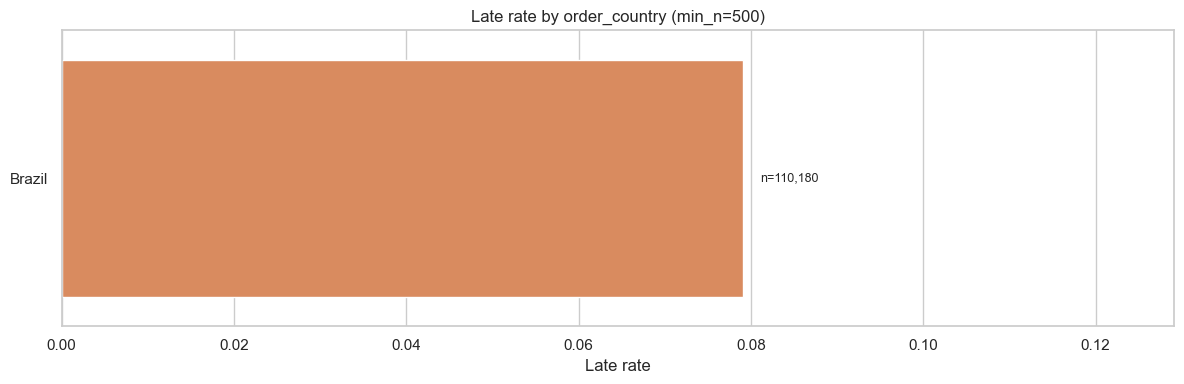

,late_rate,n
order_country,,
Brazil,0.079089,110180


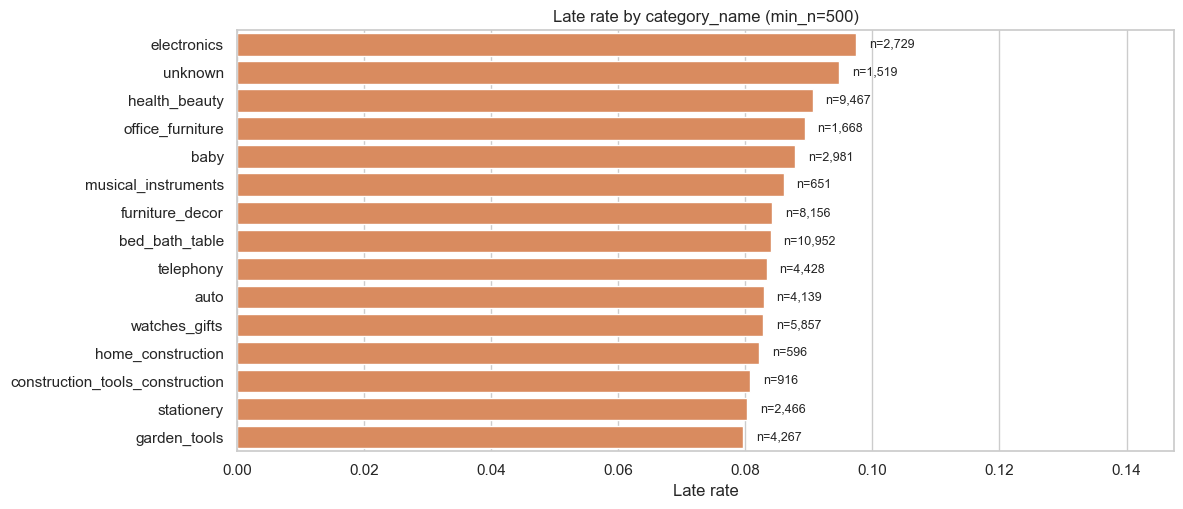

,late_rate,n
category_name,,
electronics,0.097472,2729
unknown,0.094799,1519
health_beauty,0.090631,9467
office_furniture,0.089329,1668
baby,0.087890,2981
musical_instruments,0.086022,651
furniture_decor,0.084232,8156
bed_bath_table,0.084003,10952
telephony,0.083333,4428


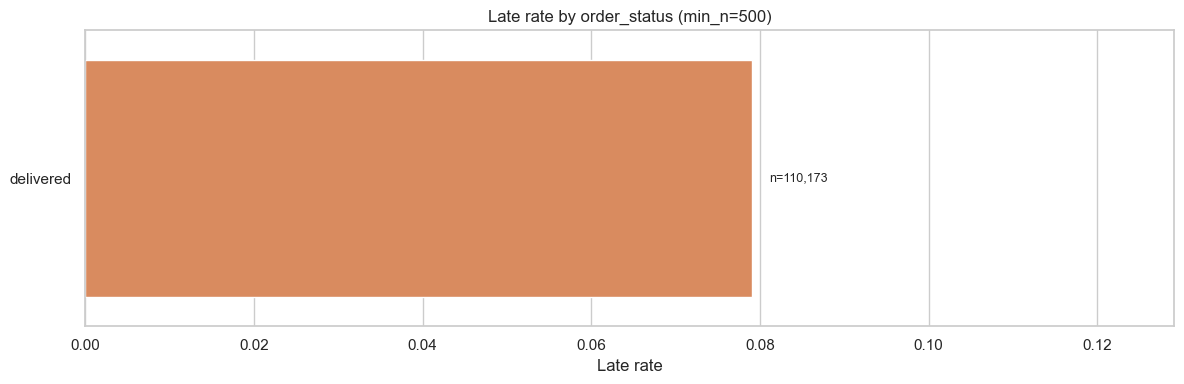

,late_rate,n
order_status,,
delivered,0.079085,110173


In [7]:
# ---- Categorical drivers (late-rate by segment with volume) ----

cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print(f"Categorical columns: {len(cat_cols)}")

# High-signal business segments in this dataset
key_cats = [
    "shipping_mode",
    "market",
    "order_region",
    "order_country",
    "customer_segment",
    "department_name",
    "category_name",
    "transaction_type",
    "order_status",
]
key_cats = [c for c in key_cats if c in df.columns]
print("Key categorical columns found:", key_cats)


def late_rate_table(col: str, top_k: int = 15, min_n: int = 200) -> pd.DataFrame:
    g = df.groupby(col)[TARGET].agg(["mean", "size"]).rename(columns={"mean": "late_rate", "size": "n"})
    g = g[g["n"] >= min_n].sort_values(["late_rate", "n"], ascending=[False, False])
    if len(g) > top_k:
        g = g.head(top_k)
    return g


def plot_late_rate(col: str, top_k: int = 15, min_n: int = 200):
    t = late_rate_table(col, top_k=top_k, min_n=min_n)
    if len(t) == 0:
        print(f"No groups meet min_n={min_n} for {col}.")
        return

    plot_df = t.reset_index()
    plt.figure(figsize=(12, max(4, 0.35 * len(plot_df))))
    ax = sns.barplot(data=plot_df, y=col, x="late_rate", hue=None, color=sns.color_palette()[1])

    for i, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(row["late_rate"] + 0.002, i, f"n={int(row['n']):,}", va="center", fontsize=9)

    plt.xlim(0, min(1.0, max(plot_df["late_rate"].max() + 0.05, 0.1)))
    plt.title(f"Late rate by {col} (min_n={min_n})")
    plt.xlabel("Late rate")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    display(t)


for c in key_cats:
    plot_late_rate(c, top_k=15, min_n=500)


### Step 7 – Time patterns in late delivery

We want to know **when** late deliveries tend to happen.

Using the cleaned `order_date` column we:
- Convert it to a proper datetime and drop invalid dates.
- Resample by **month** to compute monthly **late rate** and **order volume**.
- Plot a combined chart:
  - Line = late rate over time.
  - Bars = number of orders per month.
- Also derive **day-of-week** and plot late rate by weekday.

This reveals **seasonality or operational issues** (e.g., specific months or weekdays with systematically higher late risk).

Unparseable order_date: 0.00%


,late_rate,orders
order_date,,
2016-09-01,1.000000,3
2016-10-01,0.009404,319
2016-11-01,NaN,0
2016-12-01,0.000000,1
2017-01-01,0.028540,911


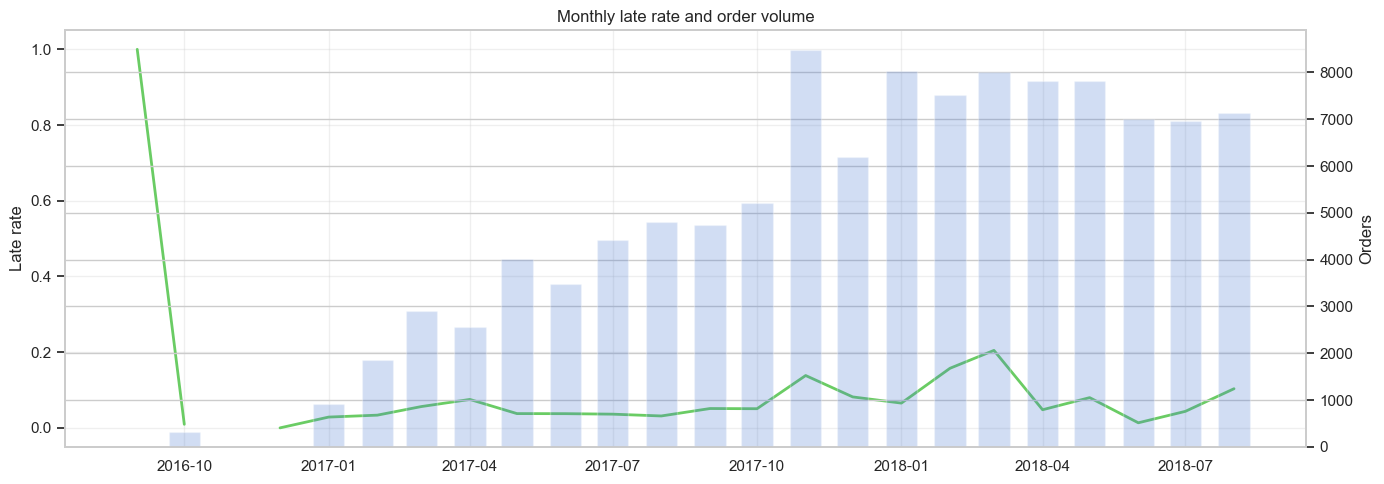

,late_rate,n
dow,,
Monday,0.087789,17975
Tuesday,0.083161,17857
Wednesday,0.075565,17217
Thursday,0.074006,16431
Friday,0.081369,15694
Saturday,0.073167,11877
Sunday,0.075253,13129


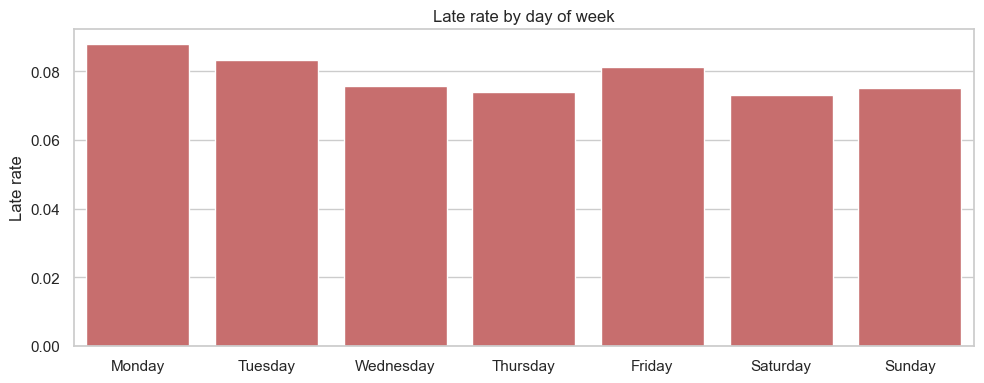

In [8]:
# ---- Time trends (order date) ----

date_col = "order_date"
if date_col in df.columns:
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    bad = d[date_col].isna().mean()
    print(f"Unparseable {date_col}: {bad:.2%}")

    d = d.dropna(subset=[date_col]).sort_values(date_col)
    d = d.set_index(date_col)

    monthly = d.resample("MS")[TARGET].agg(["mean", "size"]).rename(columns={"mean": "late_rate", "size": "orders"})
    display(monthly.head())

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(monthly.index, monthly["late_rate"], color=sns.color_palette()[2], linewidth=2)
    ax1.set_ylabel("Late rate")
    ax1.set_title("Monthly late rate and order volume")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.bar(monthly.index, monthly["orders"], width=20, alpha=0.25, color=sns.color_palette()[0])
    ax2.set_ylabel("Orders")

    plt.tight_layout()
    plt.show()

    # Day-of-week effect
    dow = d.copy()
    dow["dow"] = dow.index.day_name()
    dow_tbl = dow.groupby("dow")[TARGET].agg(["mean", "size"]).rename(columns={"mean": "late_rate", "size": "n"})
    # Order by typical week
    order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    dow_tbl = dow_tbl.reindex(order)
    display(dow_tbl)

    plt.figure(figsize=(10, 4))
    sns.barplot(data=dow_tbl.reset_index(), x="dow", y="late_rate", color=sns.color_palette()[3])
    plt.title("Late rate by day of week")
    plt.xlabel("")
    plt.ylabel("Late rate")
    plt.tight_layout()
    plt.show()
else:
    print(f"Column not found: {date_col}")


### Step 8 – Correlations with the target (numeric view)

Here we examine how strongly each numeric feature is **monotonically associated** with `late_delivery_risk`.

- We take all numeric columns and compute a **Spearman correlation matrix**.
- We sort features by absolute correlation with the target and list the **top 20**.
- For the strongest ones, we plot a **heatmap** of the correlation sub-matrix.

This gives a quick sense of which numeric signals are most relevant for modeling (keeping in mind that some may still be leakage or highly redundant with others).

is_late                     1.000000
delivery_days               0.391958
shipping_days_actual        0.391958
review_score               -0.275265
freight_value               0.054470
shipping_days_scheduled    -0.050019
customer_zip_code_prefix    0.038446
item_total                  0.029659
price                       0.024321
item_sales                  0.024321
product_price               0.024321
seller_zip_code_prefix     -0.024099
order_item_id              -0.020078
product_weight_g            0.017921
customer_total_sales        0.015791
payment_value               0.015736
product_length_cm           0.009948
is_high_value               0.008705
product_height_cm           0.008275
product_photos_qty         -0.008007
Name: late_delivery_risk, dtype: float64

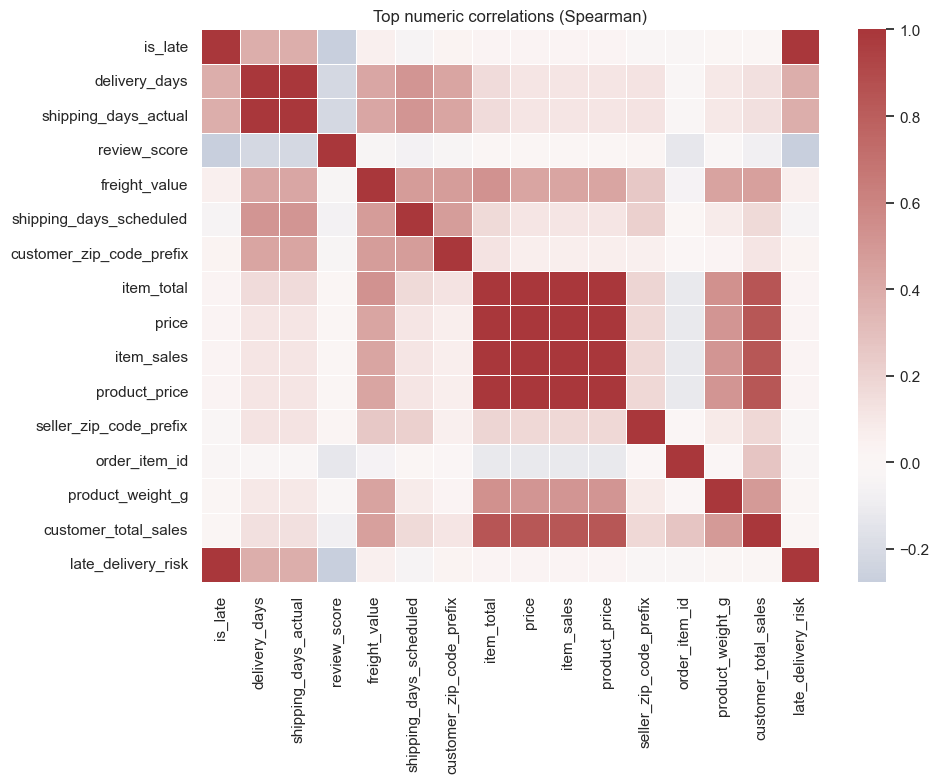

In [9]:
# ---- Correlations (numeric) + relationship to target ----

num = df.select_dtypes(include=["number"]).copy()
if TARGET in num.columns:
    # Spearman tends to be more robust with heavy skew
    corr = num.corr(method="spearman")

    # Show strongest relationships with target (excluding obvious leakage if present)
    s = corr[TARGET].drop(labels=[TARGET], errors="ignore").sort_values(key=lambda x: x.abs(), ascending=False)
    display(s.head(20))

    # Heatmap on a manageable subset
    top_cols = s.head(15).index.tolist() + [TARGET]
    top_corr = corr.loc[top_cols, top_cols]

    plt.figure(figsize=(10, 8))
    sns.heatmap(top_corr, annot=False, cmap="vlag", center=0, linewidths=0.5)
    plt.title("Top numeric correlations (Spearman)")
    plt.tight_layout()
    plt.show()
else:
    print("Target not numeric; skipping correlation analysis.")


### Step 9 – Geographic sanity check

We use `store_latitude` and `store_longitude` to see if there are **geographic clusters** of high late risk.

- We sample up to 10,000 orders for readability.
- We plot points in latitude/longitude space, colored by `late_delivery_risk`.

This isn’t a precise spatial model, but it can show whether particular **regions or countries** stand out visually as late-delivery hotspots.

In [13]:
# ---- Geo sanity (sampled) ----

lat_col, lon_col = "store_latitude", "store_longitude"
if lat_col in df.columns and lon_col in df.columns:
    g = df[[lat_col, lon_col, TARGET]].dropna().copy()
    if len(g) > 10_000:
        g = g.sample(10_000, random_state=42)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=g,
        x=lon_col,
        y=lat_col,
        hue=TARGET,
        alpha=0.35,
        s=12,
        palette={0: sns.color_palette()[0], 1: sns.color_palette()[2]},
        linewidth=0,
    )
    plt.title("Geo scatter (sampled) colored by late risk")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend(title=TARGET)
    plt.tight_layout()
    plt.show()
else:
    print("Latitude/Longitude not found; skipping geo plot.")


Latitude/Longitude not found; skipping geo plot.


In [ ]:
#shapefiles. "Where is the most lateness coming from. plot it in a map u have a location. geographic plot. onto a streamlit dashboard. tablue, or in python. if powerbi not posssible"

### Step 10 –  insight summary

Finally, we summarize the **most important segments** where late rate is meaningfully different from the global baseline.

- We compute the overall **baseline late rate**.
- For key segment columns (e.g., `shipping_mode`, `market`, `order_region`), we calculate per-group:
  - number of orders `n`
  - late rate
  - **lift in percentage points** vs baseline.
- We rank segments by a combined **score** that favors both **large lift** and **large volume**.
- We display the top rows in a table and print **ready-to-use bullet sentences** like:
  
  > `shipping_mode = Same Day: late rate 18.2% (5.4 pp higher than baseline; n=12,345)`

These bullets are meant to drop directly into your report or slides as data-backed findings.


## What to extract from this EDA (deliverables)

- **Operational levers**: which `Shipping Mode`, `Market`, `Order Region/Country`, and product segments have materially higher late rates **at meaningful volume**.
- **Seasonality**: whether late delivery spikes by month / day-of-week.
- **Financial trade-offs**: how discounting, quantities, and product price relate to late risk (and whether those relationships are confounded by region/market).
- **Leakage risks**: columns that encode outcomes (e.g., actual shipping days, delivery status) must not be used as predictors.

If you want, we can add a final “Insight Summary” section that programmatically prints the top 10 highest-confidence findings (with counts + late-rate deltas).


In [11]:
# ---- Insight summary (high-confidence, report-ready) ----

baseline = float(df[TARGET].mean())
print(f"Overall late rate: {baseline:.3f} ({baseline*100:.1f}%)")

summary_cols = [c for c in ["shipping_mode", "market", "order_region", "order_country", "customer_segment", "department_name", "category_name"] if c in df.columns]

rows = []
for col in summary_cols:
    tbl = df.groupby(col)[TARGET].agg(["mean", "size"]).rename(columns={"mean": "late_rate", "size": "n"})
    # keep meaningful volume; adjust threshold if needed
    tbl = tbl[tbl["n"] >= 1000].copy()
    if len(tbl) == 0:
        continue
    tbl["lift_pp"] = (tbl["late_rate"] - baseline) * 100
    tbl["col"] = col
    tbl["level"] = tbl.index.astype(str)
    rows.append(tbl.reset_index(drop=True)[["col", "level", "n", "late_rate", "lift_pp"]])

if len(rows) == 0:
    print("No summary segments met the minimum volume threshold.")
else:
    summary = pd.concat(rows, ignore_index=True)
    # “highest-confidence” = big volume + big lift
    summary["score"] = summary["lift_pp"].abs() * np.log10(summary["n"].clip(lower=2))
    summary = summary.sort_values(["score", "lift_pp"], ascending=[False, False])

    display(summary.head(25).drop(columns=["score"]))

    print("\nReport bullets (copy/paste):")
    for _, r in summary.head(10).iterrows():
        direction = "higher" if r["lift_pp"] > 0 else "lower"
        print(
            f"- {r['col']} = {r['level']}: late rate {r['late_rate']*100:.1f}% "
            f"({abs(r['lift_pp']):.1f} pp {direction} than baseline; n={int(r['n']):,})"
        )


Overall late rate: 0.079 (7.9%)


,col,level,n,late_rate,lift_pp
13,category_name,luggage_accessories,1077,0.053853,-2.523547
7,category_name,electronics,2729,0.097472,1.838284
16,category_name,pet_shop,1924,0.061331,-1.775820
8,category_name,fashion_bags_accessories,1986,0.062437,-1.665170
12,category_name,housewares,6795,0.064901,-1.418810
21,category_name,unknown,1519,0.094799,1.571045
11,category_name,health_beauty,9467,0.090631,1.154185
6,category_name,cool_stuff,3715,0.067564,-1.152483
14,category_name,office_furniture,1668,0.089329,1.023977
2,category_name,baby,2981,0.087890,0.880121



Report bullets (copy/paste):
- category_name = luggage_accessories: late rate 5.4% (2.5 pp lower than baseline; n=1,077)
- category_name = electronics: late rate 9.7% (1.8 pp higher than baseline; n=2,729)
- category_name = pet_shop: late rate 6.1% (1.8 pp lower than baseline; n=1,924)
- category_name = fashion_bags_accessories: late rate 6.2% (1.7 pp lower than baseline; n=1,986)
- category_name = housewares: late rate 6.5% (1.4 pp lower than baseline; n=6,795)
- category_name = unknown: late rate 9.5% (1.6 pp higher than baseline; n=1,519)
- category_name = health_beauty: late rate 9.1% (1.2 pp higher than baseline; n=9,467)
- category_name = cool_stuff: late rate 6.8% (1.2 pp lower than baseline; n=3,715)
- category_name = office_furniture: late rate 8.9% (1.0 pp higher than baseline; n=1,668)
- category_name = baby: late rate 8.8% (0.9 pp higher than baseline; n=2,981)


In [ ]:
#also region level, from the time seasonality level, from product level,why is the lateness happening??? just make a dashboard at the end, recommendations as well. plot or insight. a little of text and tables. "WHAT recommendation can i give to the business to reduce the latness, suggest actions."